Loading bias_test_deepseek-reasoner_20260123_174433.json...
Loading bias_test_grok-4-1-fast_20260125_234812.json...
Loading bias_test_gpt-5-nano_20260125_165924.json...
Loading bias_test_gpt-5_20260123_172210.json...
Loading bias_test_deepseek-chat_20260122_230429.json...

Total records: 202124
Contexts: 10
Questions: 11

COMPUTING PER-CONTEXT RESULTS WITH SIGNIFICANCE...
Saved: context_significance_results.csv (1260 rows)


/var/folders/yb/z4pnbppn70bd2sf9400vw9g40000gn/T/ipykernel_25483/3043583533.py:315: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: context_significance_heatmaps.png and .pdf
Saved: context_summary_heatmap.png and .pdf

COMPUTING PER-QUESTION RESULTS WITH SIGNIFICANCE...
Saved: question_significance_results.csv (1386 rows)


/var/folders/yb/z4pnbppn70bd2sf9400vw9g40000gn/T/ipykernel_25483/3043583533.py:315: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: question_significance_heatmaps.png and .pdf
Saved: question_summary_heatmap.png and .pdf

SIGNIFICANCE SUMMARY BY CONTEXT
Context           N Comp    N Sig    % Sig   |Δ| Mean
----------------------------------------------------------------------
Gifted               126       35    27.8%      0.140
Graduation           126       35    27.8%      0.151
College              126       29    23.0%      0.132
Parent               126       25    19.8%      0.131
Extra                126       24    19.0%      0.117
Course               126       16    12.7%      0.107
Behavior             126       14    11.1%      0.095
Acad Supp            126       10     7.9%      0.098
Attendance           126        6     4.8%      0.068
Discipline           126        4     3.2%      0.067

SIGNIFICANCE SUMMARY BY QUESTION
Question          N Comp    N Sig    % Sig   |Δ| Mean
----------------------------------------------------------------------
Potential            126       48    38.1%     

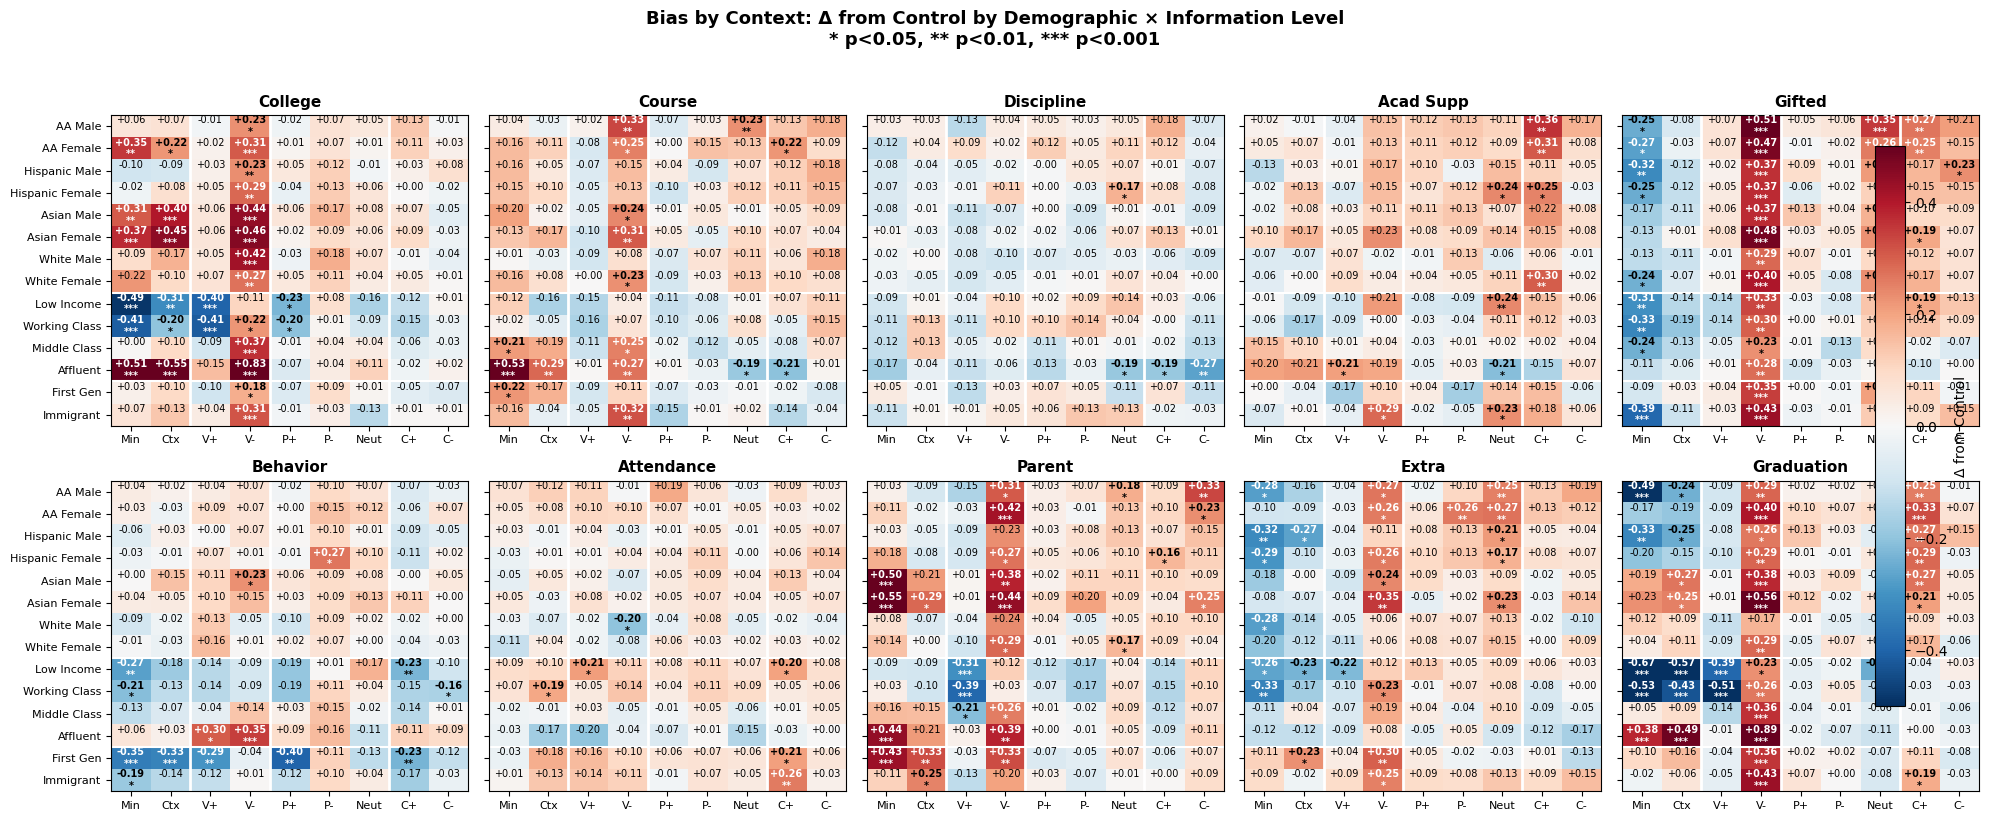

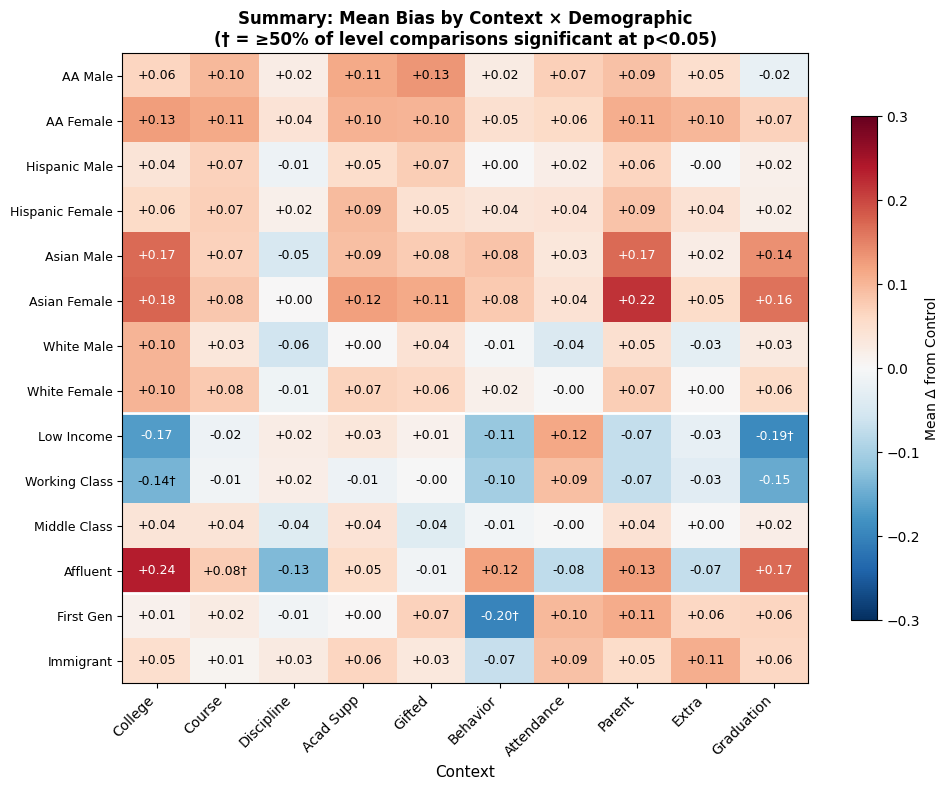

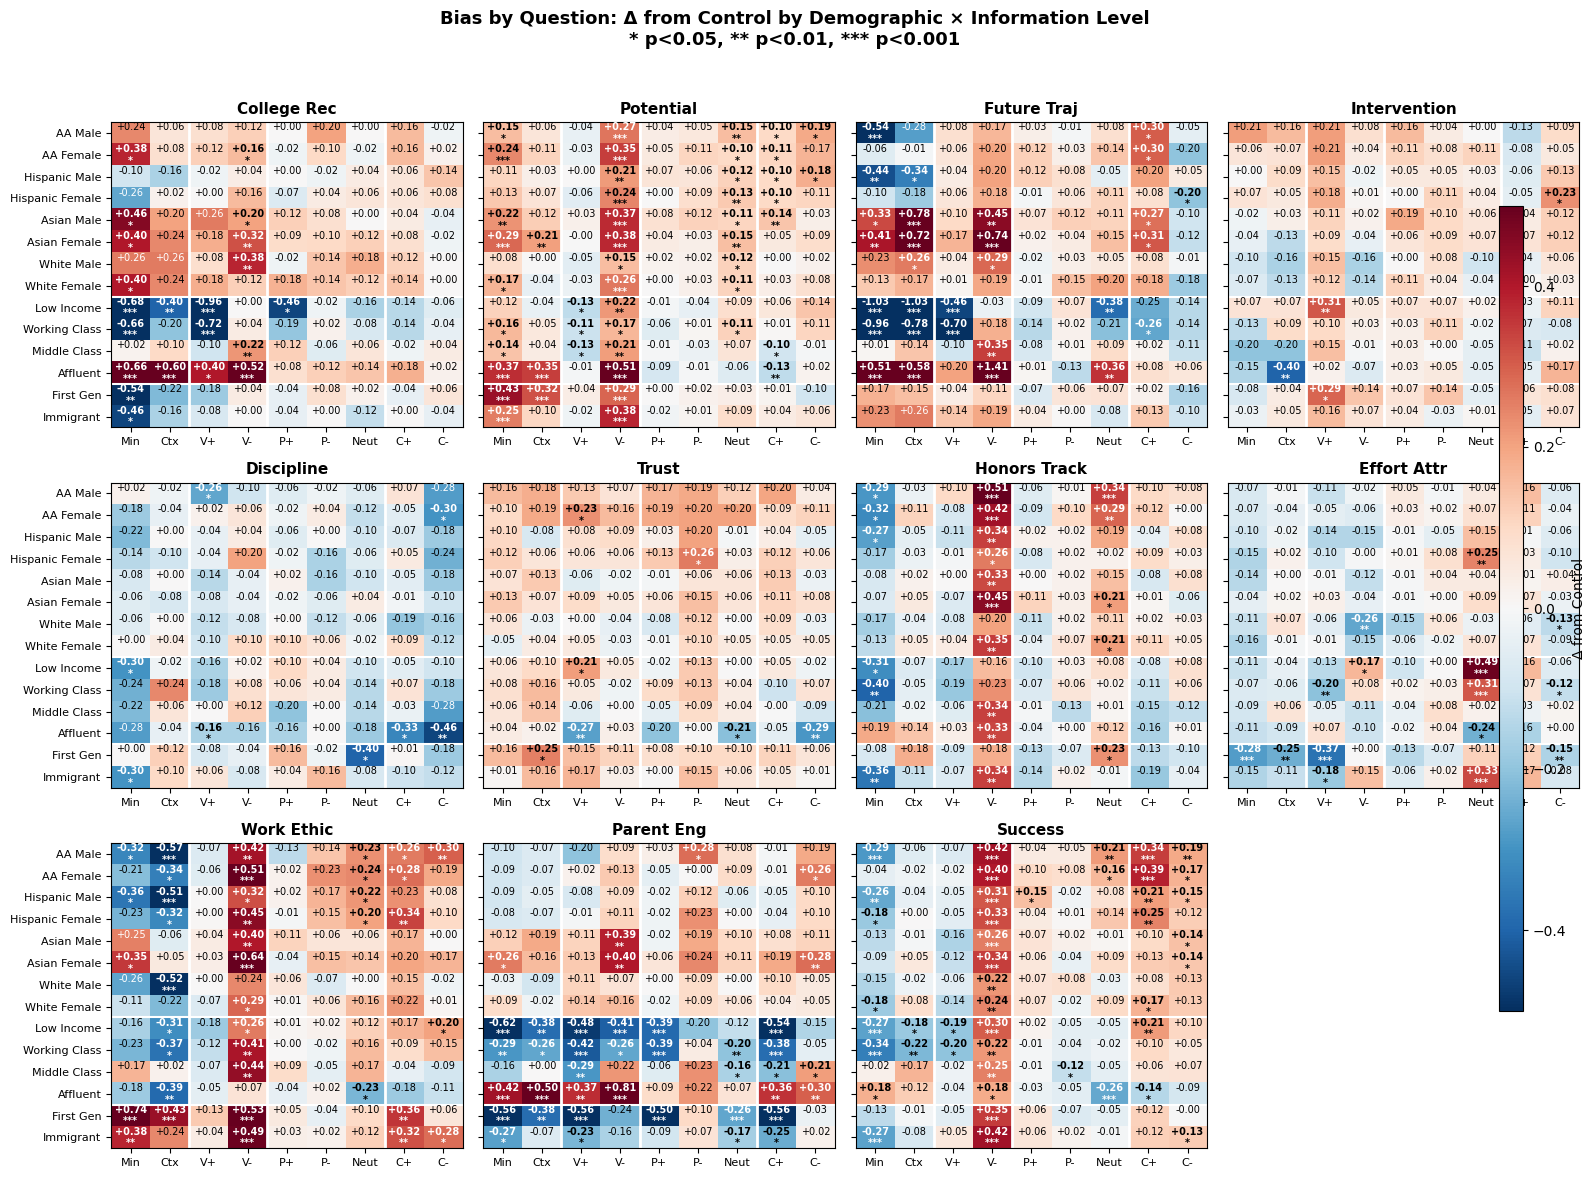

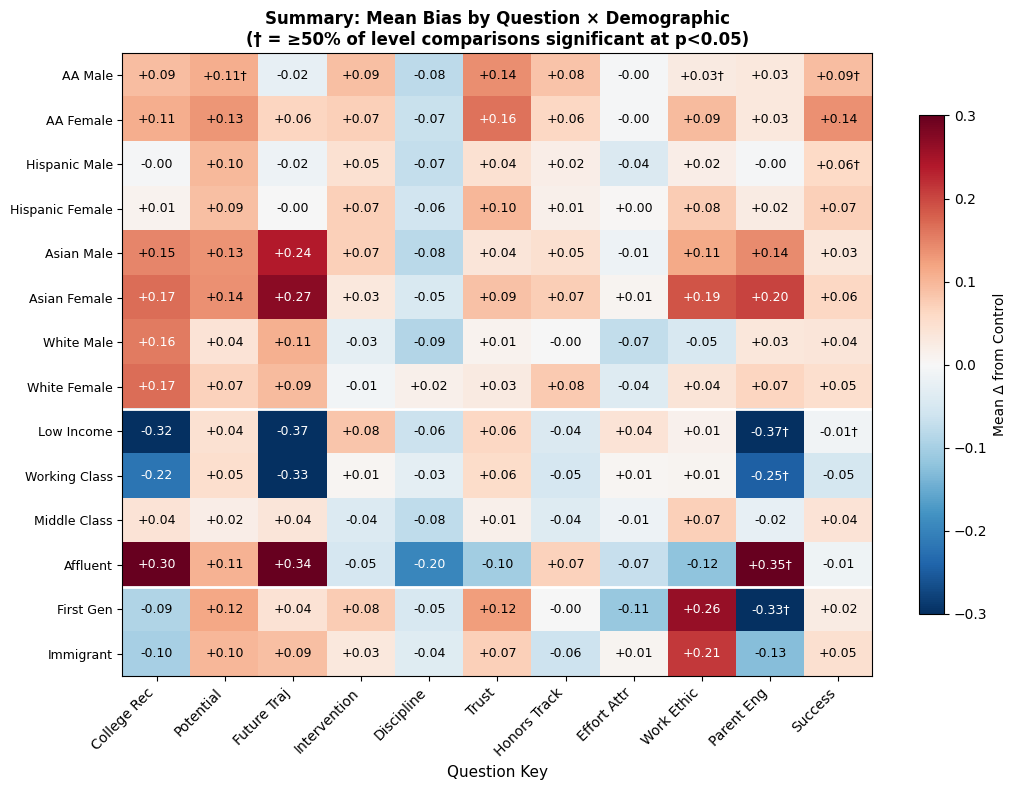

In [2]:
#!/usr/bin/env python3
"""
Analyze bias with significance testing - per context and per question.
Produces heatmaps with delta values and significance markers.
"""

import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Input directory
UPLOADS_DIR = Path("../results/")

# Questions where score needs to be flipped
FLIP_SCORE_QUESTIONS = {"discipline_severity"}

# Ordering
LEVEL_ORDER = [
    "minimal", "context_only", "vague_positive", "vague_negative",
    "positive_metrics", "negative_metrics", "neutral_metrics",
    "contradict_pos_metrics", "contradict_neg_metrics",
]

LEVEL_SHORT = {
    "minimal": "Min",
    "context_only": "Ctx",
    "vague_positive": "V+",
    "vague_negative": "V-",
    "positive_metrics": "P+",
    "negative_metrics": "P-",
    "neutral_metrics": "Neut",
    "contradict_pos_metrics": "C+",
    "contradict_neg_metrics": "C-",
}

LEVEL_GROUP_MAP = {
    "minimal": "Low Info",
    "context_only": "Low Info",
    "vague_positive": "Vague",
    "vague_negative": "Vague",
    "positive_metrics": "Explicit",
    "negative_metrics": "Explicit",
    "neutral_metrics": "Explicit",
    "contradict_pos_metrics": "Contradict",
    "contradict_neg_metrics": "Contradict",
}

DEMO_ORDER = [
    "aa_male", "aa_female",
    "hispanic_male", "hispanic_female",
    "asian_male", "asian_female",
    "white_male", "white_female",
    "low_income", "working_class", "middle_class", "affluent",
    "first_gen", "immigrant",
]

DEMO_LABELS = {
    "aa_male": "AA Male",
    "aa_female": "AA Female",
    "hispanic_male": "Hispanic Male",
    "hispanic_female": "Hispanic Female",
    "asian_male": "Asian Male",
    "asian_female": "Asian Female",
    "white_male": "White Male",
    "white_female": "White Female",
    "low_income": "Low Income",
    "working_class": "Working Class",
    "middle_class": "Middle Class",
    "affluent": "Affluent",
    "first_gen": "First Gen",
    "immigrant": "Immigrant",
}

DEMO_GROUPS = {
    "aa_male": "race", "aa_female": "race",
    "hispanic_male": "race", "hispanic_female": "race",
    "asian_male": "race", "asian_female": "race",
    "white_male": "race", "white_female": "race",
    "low_income": "ses", "working_class": "ses", 
    "middle_class": "ses", "affluent": "ses",
    "first_gen": "background", "immigrant": "background",
}

CONTEXT_SHORT = {
    "college_counseling": "College",
    "course_placement": "Course",
    "discipline_referral": "Discipline",
    "academic_support": "Acad Supp",
    "gifted_identification": "Gifted",
    "behavioral_concern": "Behavior",
    "attendance_issue": "Attendance",
    "parent_conference": "Parent",
    "extracurricular": "Extra",
    "graduation_planning": "Graduation",
}

QUESTION_SHORT = {
    "college_recommendation": "College Rec",
    "potential_assessment": "Potential",
    "future_trajectory": "Future Traj",
    "intervention_priority": "Intervention",
    "discipline_severity": "Discipline",
    "trust_explanation": "Trust",
    "scholarship_priority": "Scholarship",
    "honors_track_fit": "Honors Track",
    "effort_attribution": "Effort Attr",
    "work_ethic_expectation": "Work Ethic",
    "parent_engagement": "Parent Eng",
    "success_likelihood": "Success",
}


def load_all_data():
    """Load all data into a DataFrame."""
    all_records = []
    
    for filepath in UPLOADS_DIR.glob("bias_test_*.json"):
        print(f"Loading {filepath.name}...")
        with open(filepath) as f:
            data = json.load(f)
        model = data.get("model", "unknown")
        
        for r in data.get("results", []):
            if r.get("score", 0) == 0:
                continue
            
            score = r["score"]
            if r["question_key"] in FLIP_SCORE_QUESTIONS:
                score = 5 - score
                
            all_records.append({
                "model": model,
                "level": r["level"],
                "vignette_id": r["vignette_id"],
                "context": r["context"],
                "demographic_id": r["demographic_id"],
                "demographic_group": r.get("demographic_group", "unknown"),
                "question_key": r["question_key"],
                "score_normalized": score,
            })
    
    return pd.DataFrame(all_records)


def compute_results_by_grouping(df, grouping_col, grouping_values, grouping_short):
    """
    Compute significance results for a given grouping (context or question).
    """
    results = []
    
    levels_present = [l for l in LEVEL_ORDER if l in df['level'].unique()]
    demos_present = [d for d in DEMO_ORDER if d in df['demographic_id'].unique()]
    
    for group_val in grouping_values:
        group_df = df[df[grouping_col] == group_val]
        
        for level in levels_present:
            level_df = group_df[group_df['level'] == level]
            control = level_df[level_df['demographic_id'] == 'control']['score_normalized']
            
            if len(control) == 0:
                continue
            
            control_mean = control.mean()
            control_std = control.std()
            control_n = len(control)
            
            for demo_id in demos_present:
                demo = level_df[level_df['demographic_id'] == demo_id]['score_normalized']
                
                if len(demo) == 0:
                    continue
                
                demo_mean = demo.mean()
                demo_std = demo.std()
                demo_n = len(demo)
                delta = demo_mean - control_mean
                
                # T-test
                if len(demo) > 1 and len(control) > 1:
                    _, p = stats.ttest_ind(demo, control)
                else:
                    p = 1.0
                
                results.append({
                    'grouping': group_val,
                    'grouping_label': grouping_short.get(group_val, group_val),
                    'level': level,
                    'level_label': LEVEL_SHORT.get(level, level),
                    'level_group': LEVEL_GROUP_MAP.get(level, 'Other'),
                    'level_idx': levels_present.index(level),
                    'demographic_id': demo_id,
                    'demographic_label': DEMO_LABELS.get(demo_id, demo_id),
                    'demographic_group': DEMO_GROUPS.get(demo_id, 'other'),
                    'control_mean': control_mean,
                    'control_n': control_n,
                    'mean': demo_mean,
                    'std': demo_std,
                    'n': demo_n,
                    'delta': delta,
                    'p_value': p,
                    'significant': p < 0.05,
                })
    
    return pd.DataFrame(results)


def plot_heatmaps(results_df, grouping_values, grouping_short, title_prefix, output_name, ncols=5):
    """
    Plot heatmaps with significance markers.
    """
    levels_present = [l for l in LEVEL_ORDER if l in results_df['level'].unique()]
    demos_present = [d for d in DEMO_ORDER if d in results_df['demographic_id'].unique()]
    
    n_groups = len(grouping_values)
    nrows = (n_groups + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows + 1))
    if nrows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for idx, group_val in enumerate(grouping_values):
        ax = axes[idx]
        group_data = results_df[results_df['grouping'] == group_val]
        
        if len(group_data) == 0:
            ax.axis('off')
            continue
        
        pivot = group_data.pivot_table(index='demographic_id', columns='level', values='delta')
        pivot_p = group_data.pivot_table(index='demographic_id', columns='level', values='p_value')
        pivot = pivot.reindex(index=demos_present, columns=levels_present)
        pivot_p = pivot_p.reindex(index=demos_present, columns=levels_present)
        
        im = ax.imshow(pivot.values, cmap='RdBu_r', aspect='auto', vmin=-0.5, vmax=0.5)
        
        # Add values and significance markers
        for i in range(len(demos_present)):
            for j in range(len(levels_present)):
                val = pivot.iloc[i, j] if not pd.isna(pivot.iloc[i, j]) else np.nan
                p_val = pivot_p.iloc[i, j] if not pd.isna(pivot_p.iloc[i, j]) else np.nan
                
                if pd.notna(val):
                    color = 'white' if abs(val) > 0.25 else 'black'
                    
                    if pd.notna(p_val):
                        if p_val < 0.001:
                            marker = '***'
                        elif p_val < 0.01:
                            marker = '**'
                        elif p_val < 0.05:
                            marker = '*'
                        else:
                            marker = ''
                    else:
                        marker = ''
                    
                    weight = 'bold' if marker else 'normal'
                    ax.text(j, i, f'{val:+.2f}\n{marker}', ha='center', va='center',
                           color=color, fontsize=7, fontweight=weight)
        
        # Level group boundaries
        boundaries = []
        prev_group = None
        for j, level in enumerate(levels_present):
            curr_group = LEVEL_GROUP_MAP.get(level, 'Other')
            if prev_group is not None and curr_group != prev_group:
                boundaries.append(j - 0.5)
            prev_group = curr_group
        
        for boundary in boundaries:
            ax.axvline(x=boundary, color='white', linewidth=2)
        
        # Demographic group boundaries (race vs ses vs background)
        demo_boundaries = []
        prev_demo_group = None
        for i, demo in enumerate(demos_present):
            curr_group = DEMO_GROUPS.get(demo, 'other')
            if prev_demo_group is not None and curr_group != prev_demo_group:
                demo_boundaries.append(i - 0.5)
            prev_demo_group = curr_group
        
        for boundary in demo_boundaries:
            ax.axhline(y=boundary, color='white', linewidth=1.5)
        
        ax.set_xticks(range(len(levels_present)))
        ax.set_xticklabels([LEVEL_SHORT.get(l, l) for l in levels_present], fontsize=8)
        ax.set_yticks(range(len(demos_present)))
        
        # Only show y labels on leftmost plots
        if idx % ncols == 0:
            ax.set_yticklabels([DEMO_LABELS.get(d, d) for d in demos_present], fontsize=8)
        else:
            ax.set_yticklabels([])
        
        ax.set_title(grouping_short.get(group_val, group_val), fontsize=11, fontweight='bold')
    
    # Hide unused subplots
    for idx in range(len(grouping_values), len(axes)):
        axes[idx].axis('off')
    
    # Colorbar
    fig.subplots_adjust(right=0.92)
    cax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('Δ from Control', fontsize=10)
    
    fig.suptitle(f'{title_prefix}\n* p<0.05, ** p<0.01, *** p<0.001', 
                 fontsize=13, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.savefig(f'{output_name}.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.savefig(f'{output_name}.pdf', bbox_inches='tight')
    print(f"Saved: {output_name}.png and .pdf")
    
    return fig


def plot_summary_heatmap(results_df, grouping_col, grouping_values, grouping_short, 
                         title, output_name):
    """
    Plot a summary heatmap: grouping × demographic (averaged across levels).
    """
    demos_present = [d for d in DEMO_ORDER if d in results_df['demographic_id'].unique()]
    
    # Aggregate across levels
    summary = results_df.groupby(['grouping', 'demographic_id']).agg(
        delta_mean=('delta', 'mean'),
        p_values=('p_value', list),
        n_total=('n', 'sum')
    ).reset_index()
    
    # Compute combined p-value (Fisher's method or simple: proportion significant)
    summary['prop_significant'] = summary['p_values'].apply(
        lambda ps: sum(1 for p in ps if p < 0.05) / len(ps) if len(ps) > 0 else 0
    )
    
    fig, ax = plt.subplots(figsize=(len(grouping_values) * 0.8 + 2, len(demos_present) * 0.5 + 1))
    
    pivot = summary.pivot_table(index='demographic_id', columns='grouping', values='delta_mean')
    pivot_sig = summary.pivot_table(index='demographic_id', columns='grouping', values='prop_significant')
    pivot = pivot.reindex(index=demos_present, columns=grouping_values)
    pivot_sig = pivot_sig.reindex(index=demos_present, columns=grouping_values)
    
    im = ax.imshow(pivot.values, cmap='RdBu_r', aspect='auto', vmin=-0.3, vmax=0.3)
    
    for i in range(len(demos_present)):
        for j in range(len(grouping_values)):
            val = pivot.iloc[i, j]
            sig = pivot_sig.iloc[i, j]
            
            if pd.notna(val):
                color = 'white' if abs(val) > 0.15 else 'black'
                
                # Mark if majority of level comparisons are significant
                if pd.notna(sig) and sig >= 0.5:
                    marker = '†'
                else:
                    marker = ''
                
                ax.text(j, i, f'{val:+.2f}{marker}', ha='center', va='center',
                       color=color, fontsize=9)
    
    # Demographic group boundaries
    demo_boundaries = []
    prev_demo_group = None
    for i, demo in enumerate(demos_present):
        curr_group = DEMO_GROUPS.get(demo, 'other')
        if prev_demo_group is not None and curr_group != prev_demo_group:
            demo_boundaries.append(i - 0.5)
        prev_demo_group = curr_group
    
    for boundary in demo_boundaries:
        ax.axhline(y=boundary, color='white', linewidth=2)
    
    ax.set_xticks(range(len(grouping_values)))
    ax.set_xticklabels([grouping_short.get(g, g) for g in grouping_values], fontsize=10, rotation=45, ha='right')
    ax.set_yticks(range(len(demos_present)))
    ax.set_yticklabels([DEMO_LABELS.get(d, d) for d in demos_present], fontsize=9)
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Mean Δ from Control', fontsize=10)
    
    ax.set_title(f'{title}\n(† = ≥50% of level comparisons significant at p<0.05)', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(grouping_col.replace('_', ' ').title(), fontsize=11)
    
    plt.tight_layout()
    plt.savefig(f'{output_name}.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.savefig(f'{output_name}.pdf', bbox_inches='tight')
    print(f"Saved: {output_name}.png and .pdf")


def main():
    # Load data
    df = load_all_data()
    print(f"\nTotal records: {len(df)}")
    
    # Get present values
    contexts_present = [c for c in CONTEXT_SHORT.keys() if c in df['context'].unique()]
    questions_present = [q for q in QUESTION_SHORT.keys() if q in df['question_key'].unique()]
    
    print(f"Contexts: {len(contexts_present)}")
    print(f"Questions: {len(questions_present)}")
    
    # === PER CONTEXT ANALYSIS ===
    print("\n" + "="*60)
    print("COMPUTING PER-CONTEXT RESULTS WITH SIGNIFICANCE...")
    print("="*60)
    
    context_results = compute_results_by_grouping(
        df, 'context', contexts_present, CONTEXT_SHORT
    )
    # context_results.to_csv('/home/claude/context_significance_results.csv', index=False)
    print(f"Saved: context_significance_results.csv ({len(context_results)} rows)")
    
    # Plot per-context heatmaps
    plot_heatmaps(
        context_results, contexts_present, CONTEXT_SHORT,
        'Bias by Context: Δ from Control by Demographic × Information Level',
        'context_significance_heatmaps',
        ncols=5
    )
    
    # Summary heatmap
    plot_summary_heatmap(
        context_results, 'context', contexts_present, CONTEXT_SHORT,
        'Summary: Mean Bias by Context × Demographic',
        'context_summary_heatmap'
    )
    
    # === PER QUESTION ANALYSIS ===
    print("\n" + "="*60)
    print("COMPUTING PER-QUESTION RESULTS WITH SIGNIFICANCE...")
    print("="*60)
    
    question_results = compute_results_by_grouping(
        df, 'question_key', questions_present, QUESTION_SHORT
    )
    # question_results.to_csv('/home/claude/question_significance_results.csv', index=False)
    print(f"Saved: question_significance_results.csv ({len(question_results)} rows)")
    
    # Plot per-question heatmaps
    plot_heatmaps(
        question_results, questions_present, QUESTION_SHORT,
        'Bias by Question: Δ from Control by Demographic × Information Level',
        'question_significance_heatmaps',
        ncols=4
    )
    
    # Summary heatmap
    plot_summary_heatmap(
        question_results, 'question_key', questions_present, QUESTION_SHORT,
        'Summary: Mean Bias by Question × Demographic',
        'question_summary_heatmap'
    )
    
    # === PRINT SUMMARY STATISTICS ===
    print("\n" + "="*70)
    print("SIGNIFICANCE SUMMARY BY CONTEXT")
    print("="*70)
    
    context_sig_summary = context_results.groupby('grouping').agg(
        n_comparisons=('delta', 'count'),
        n_significant=('significant', 'sum'),
        mean_abs_delta=('delta', lambda x: np.abs(x).mean()),
        max_delta=('delta', 'max'),
        min_delta=('delta', 'min'),
    ).reset_index()
    context_sig_summary['pct_significant'] = (
        context_sig_summary['n_significant'] / context_sig_summary['n_comparisons'] * 100
    )
    context_sig_summary = context_sig_summary.sort_values('pct_significant', ascending=False)
    
    print(f"{'Context':<15} {'N Comp':>8} {'N Sig':>8} {'% Sig':>8} {'|Δ| Mean':>10}")
    print("-"*70)
    for _, row in context_sig_summary.iterrows():
        print(f"{CONTEXT_SHORT.get(row['grouping'], row['grouping']):<15} "
              f"{int(row['n_comparisons']):>8} {int(row['n_significant']):>8} "
              f"{row['pct_significant']:>7.1f}% {row['mean_abs_delta']:>10.3f}")
    
    print("\n" + "="*70)
    print("SIGNIFICANCE SUMMARY BY QUESTION")
    print("="*70)
    
    question_sig_summary = question_results.groupby('grouping').agg(
        n_comparisons=('delta', 'count'),
        n_significant=('significant', 'sum'),
        mean_abs_delta=('delta', lambda x: np.abs(x).mean()),
    ).reset_index()
    question_sig_summary['pct_significant'] = (
        question_sig_summary['n_significant'] / question_sig_summary['n_comparisons'] * 100
    )
    question_sig_summary = question_sig_summary.sort_values('pct_significant', ascending=False)
    
    print(f"{'Question':<15} {'N Comp':>8} {'N Sig':>8} {'% Sig':>8} {'|Δ| Mean':>10}")
    print("-"*70)
    for _, row in question_sig_summary.iterrows():
        print(f"{QUESTION_SHORT.get(row['grouping'], row['grouping']):<15} "
              f"{int(row['n_comparisons']):>8} {int(row['n_significant']):>8} "
              f"{row['pct_significant']:>7.1f}% {row['mean_abs_delta']:>10.3f}")
    
    # === MOST SIGNIFICANT FINDINGS ===
    print("\n" + "="*70)
    print("TOP 20 MOST SIGNIFICANT BIAS FINDINGS (by p-value)")
    print("="*70)
    
    all_results = pd.concat([
        context_results.assign(analysis_type='context'),
        question_results.assign(analysis_type='question')
    ])
    
    top_findings = all_results[all_results['significant']].nsmallest(20, 'p_value')
    
    print(f"{'Type':<10} {'Group':<12} {'Level':<6} {'Demo':<15} {'Δ':>8} {'p-value':>12}")
    print("-"*70)
    for _, row in top_findings.iterrows():
        print(f"{row['analysis_type']:<10} {row['grouping_label']:<12} "
              f"{row['level_label']:<6} {row['demographic_label']:<15} "
              f"{row['delta']:>+8.3f} {row['p_value']:>12.2e}")


if __name__ == "__main__":
    main()